Import Modules

In [2]:
import pandas as pd
import numpy as np
import random
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [4]:

Jotstar_content_consumption = pd.read_csv('datasets/Jotstar_content_consumption.csv')

Jotstar_contents = pd.read_csv('datasets/Jotstar_contents.csv')

Jotstar_subscribers = pd.read_csv('datasets/Jotstar_subscribers.csv')

Liocinema_content_consumption = pd.read_csv('datasets/liocinema_content_consumption.csv')

Liocinema_contents = pd.read_csv('datasets/liocinema_contents.csv')

Liocinema_subscribers = pd.read_csv('datasets/liocinema_subscribers.csv')

# Total Users & Growth Trends 
What is the total number of users for LioCinema and Jotstar, and how do they 
compare in terms of growth trends (January–November 2024)?

In [5]:
# convert the datatype of the subscription date column 
Jotstar_subscribers['subscription_date'] = pd.to_datetime(Jotstar_subscribers['subscription_date'])
Liocinema_subscribers['subscription_date'] = pd.to_datetime(Liocinema_subscribers['subscription_date'])

In [6]:
# groupby the data value by the subscription date and count how many users have subscribed in that month
Jotstar_subscribers_tot = Jotstar_subscribers.groupby('subscription_date')['user_id'].count().reset_index()
liocinema_subscribers_tot = Liocinema_subscribers.groupby('subscription_date')['user_id'].count().reset_index()

In [7]:
# merge both the dataset 
Total_user_per_month = pd.merge(Jotstar_subscribers_tot,liocinema_subscribers_tot, on = 'subscription_date')
Total_user_per_month = Total_user_per_month.rename(columns={'user_id_x':'Jotstar_users','user_id_y':'Liocinema_users'})

In [8]:
# group by month only to know total user on both platform for each month
Total_user_per_month['month'] = Total_user_per_month['subscription_date'].dt.to_period('M')
Total_user_per_month_df = Total_user_per_month.groupby('month')[['Jotstar_users','Liocinema_users']].sum().reset_index()

Total_user_per_month_df['month'] = Total_user_per_month_df['month'].dt.to_timestamp()
Total_user_per_month_df


,month,Jotstar_users,Liocinema_users
0,2024-01-01,3934,6758
1,2024-02-01,3939,7404
2,2024-03-01,3954,8397
3,2024-04-01,3984,9759
4,2024-05-01,3998,11977
5,2024-06-01,4020,13768
6,2024-07-01,4067,16161
7,2024-08-01,4103,19247
8,2024-09-01,4163,23873
9,2024-10-01,4196,29105


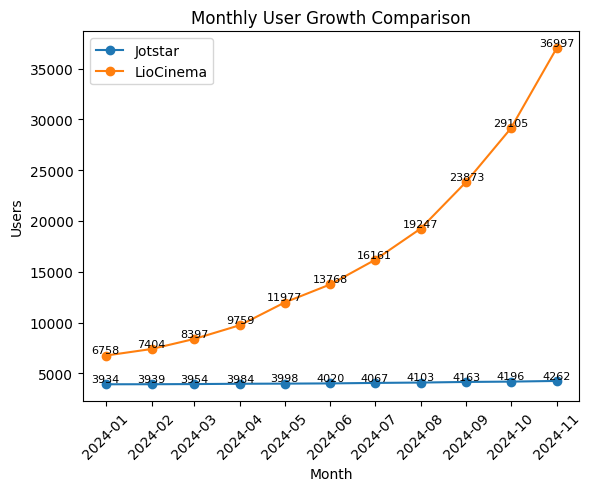

In [9]:

x = Total_user_per_month_df['month']
y1 = Total_user_per_month_df['Jotstar_users']
y2 = Total_user_per_month_df['Liocinema_users']

plt.plot(x, y1, marker='o', label='Jotstar')
plt.plot(x, y2, marker='o', label='LioCinema')

# Add labels for Jotstar
for i, value in enumerate(y1):
    plt.text(x[i], value, str(value), fontsize=8, ha='center', va='bottom')

# Add labels for LioCinema
for i, value in enumerate(y2):
    plt.text(x[i], value, str(value), fontsize=8, ha='center', va='bottom')

plt.xlabel('Month')
plt.ylabel('Users')
plt.title('Monthly User Growth Comparison')
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [10]:
Total_user_Jotstar,Total_user_Liocinema = Total_user_per_month['Jotstar_users'].sum(), Total_user_per_month['Liocinema_users'].sum()
Overall_user_db = Total_user_Liocinema + Total_user_Jotstar
print(f"Jotstar users {Total_user_Jotstar} and Liocinema users {Total_user_Liocinema}")

print(f'Overall total user database if both platforms merge = {Overall_user_db}')

print(f'Percentage share of both platform: Jotstar {round((Total_user_Jotstar/Overall_user_db)*100,2)}% and Liocinema {round((Total_user_Liocinema/Overall_user_db)*100,2)}% ')


Jotstar users 44620 and Liocinema users 183446
Overall total user database if both platforms merge = 228066
Percentage share of both platform: Jotstar 19.56% and Liocinema 80.44% 


# Content Library Comparison 
What is the total number of contents available on LioCinema vs. Jotstar? How do 
they differ in terms of language and content type?

In [11]:
# Group the data by content_type and lanaguage provide in both the platform

Jotstar_contents_tot = Jotstar_contents.groupby(['content_type','language'])['content_id'].count().reset_index()
liocinema_contents_tot = Liocinema_contents.groupby(['content_type','language'])['content_id'].count().reset_index()

In [12]:
# Merge both of the dataset using outer - to ensure all of the row are their in the result even if it has not match in another table.

content_library_comparison = pd.merge(Jotstar_contents_tot,liocinema_contents_tot, on = ['content_type', 'language'], how='outer')

content_library_comparison = content_library_comparison.rename(columns={'content_id_x':'Jotstar', 'content_id_y':'Liocinema'})
content_library_comparison.fillna(0)


,content_type,language,Jotstar,Liocinema
0,Movie,Bengali,35,0.0
1,Movie,English,359,40.0
2,Movie,Gujarati,11,0.0
3,Movie,Hindi,295,280.0
4,Movie,Kannada,70,81.0
5,Movie,Malayalam,70,90.0
6,Movie,Marathi,47,49.0
7,Movie,Punjabi,11,0.0
8,Movie,Tamil,141,171.0
9,Movie,Telugu,141,189.0


CONTENT BY LANGUAGE

In [13]:
content_library_comparison_plot = content_library_comparison.groupby('language')[['Jotstar','Liocinema']].sum().reset_index()
content_library_comparison_plot

,language,Jotstar,Liocinema
0,Bengali,60,0.0
1,English,800,56.0
2,Gujarati,28,0.0
3,Hindi,637,424.0
4,Kannada,121,118.0
5,Malayalam,118,121.0
6,Marathi,74,68.0
7,Punjabi,27,0.0
8,Tamil,251,221.0
9,Telugu,244,242.0


[Text(0, 0, '60'),
 Text(0, 0, '800'),
 Text(0, 0, '28'),
 Text(0, 0, '637'),
 Text(0, 0, '121'),
 Text(0, 0, '118'),
 Text(0, 0, '74'),
 Text(0, 0, '27'),
 Text(0, 0, '251'),
 Text(0, 0, '244')]

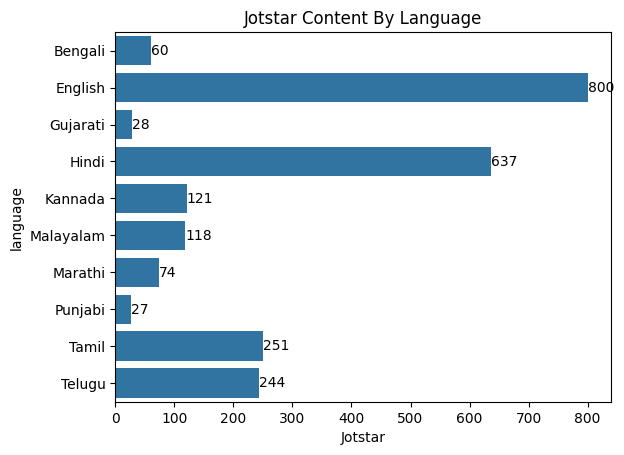

In [14]:
jotstar_ax = sns.barplot(content_library_comparison_plot,x=content_library_comparison_plot.Jotstar,y = 'language', orient='h')
plt.title('Jotstar Content By Language')
jotstar_ax.bar_label(jotstar_ax.containers[0], fontsize=10)


Text(0.5, 1.0, 'Liocinema Content By Language')

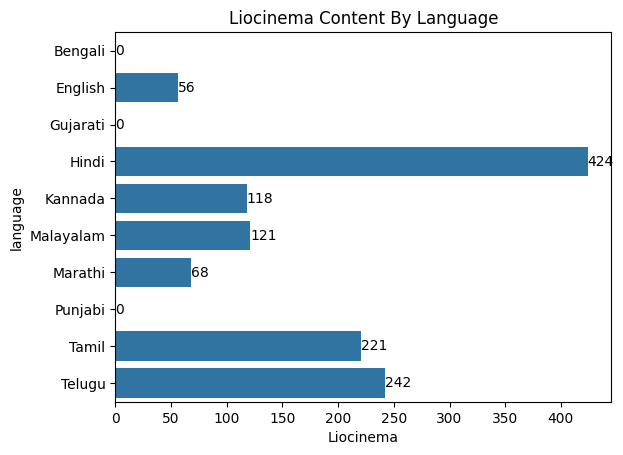

In [15]:
liocinema_ax = sns.barplot(content_library_comparison_plot,x=content_library_comparison_plot.Liocinema,y = 'language', orient='h')
liocinema_ax.bar_label(liocinema_ax.containers[0], fontsize=10)
plt.title('Liocinema Content By Language')


CONTENT BY CONTENT TYPE

In [16]:
content_library_comparison_plot = content_library_comparison.groupby('content_type')[['Jotstar','Liocinema']].sum().reset_index()
content_library_comparison_plot

,content_type,Jotstar,Liocinema
0,Movie,1180,900.0
1,Series,826,300.0
2,Sports,354,50.0


In [17]:
# change the shape of the dataset
content_library_comparison_plot = content_library_comparison_plot.melt(id_vars='content_type', value_vars=['Jotstar', 'Liocinema'], var_name='platform_users', value_name='users')
content_library_comparison_plot

,content_type,platform_users,users
0,Movie,Jotstar,1180.0
1,Series,Jotstar,826.0
2,Sports,Jotstar,354.0
3,Movie,Liocinema,900.0
4,Series,Liocinema,300.0
5,Sports,Liocinema,50.0


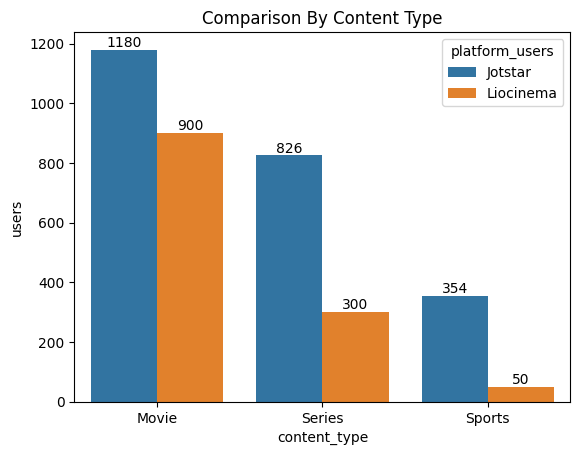

In [18]:
ax = sns.barplot(data=content_library_comparison_plot, x='content_type', y='users', hue='platform_users')
for i in ax.containers:
    ax.bar_label(i,)
plt.title('Comparison By Content Type')
plt.show()

# User Demographics 
What is the distribution of users by age group, city tier, and subscription plan for each platform ?

In [19]:
Jotstar_subscribers_demo_tot  = Jotstar_subscribers.groupby(['age_group','city_tier','subscription_plan'])['user_id'].count().reset_index()
liocinema_subscribers_demo_tot = Liocinema_subscribers.groupby(['age_group','city_tier','subscription_plan'])['user_id'].count().reset_index()

In [20]:
user_demographics = pd.merge(Jotstar_subscribers_demo_tot, liocinema_subscribers_demo_tot, on = ['age_group','city_tier','subscription_plan'],how='outer')

user_demographics = user_demographics.rename(columns={'user_id_x':'Jotstar_users','user_id_y':'Liocinema_users'})

user_demographics['Total_users'] = user_demographics.Jotstar_users + user_demographics.Liocinema_users

user_demographics = user_demographics.fillna(0)
user_demographics.head()

,age_group,city_tier,subscription_plan,Jotstar_users,Liocinema_users,Total_users
0,18-24,Tier 1,Basic,0.0,5297.0,0.0
1,18-24,Tier 1,Free,916.0,8126.0,9042.0
2,18-24,Tier 1,Premium,1773.0,4577.0,6350.0
3,18-24,Tier 1,VIP,1704.0,0.0,0.0
4,18-24,Tier 2,Basic,0.0,9924.0,0.0


DISTRIBUTION OF USERS BY AGE GROUP

In [21]:
user_demographics_age_group = user_demographics.groupby('age_group')[['Jotstar_users','Liocinema_users']].sum().reset_index()
user_demographics_age_group

,age_group,Jotstar_users,Liocinema_users
0,18-24,7676.0,79813.0
1,25-34,20069.0,52027.0
2,35-44,11274.0,32560.0
3,45+,5601.0,19046.0


DISTRIBUTION OF USERS BY SUBSCRIPTION PLAN

In [22]:
user_demographics_jotstar = user_demographics.groupby('subscription_plan')['Jotstar_users'].sum().reset_index().drop(index=0).reset_index(drop=True)
user_demographics_jotstar

,subscription_plan,Jotstar_users
0,Free,12096.0
1,Premium,13367.0
2,VIP,19157.0


In [23]:
user_demographics_liocinema = user_demographics.groupby('subscription_plan')['Liocinema_users'].sum().reset_index().drop(index=3).reset_index(drop=True)
user_demographics_liocinema

,subscription_plan,Liocinema_users
0,Basic,53362.0
1,Free,104992.0
2,Premium,25092.0


DISTRIBUTION OF USERS BY CITY TIER

In [24]:
user_demographics_city_tier = user_demographics.groupby('city_tier')[['Jotstar_users','Liocinema_users']].sum().reset_index()
user_demographics_city_tier

,city_tier,Jotstar_users,Liocinema_users
0,Tier 1,25451.0,41011.0
1,Tier 2,13424.0,63848.0
2,Tier 3,5745.0,78587.0


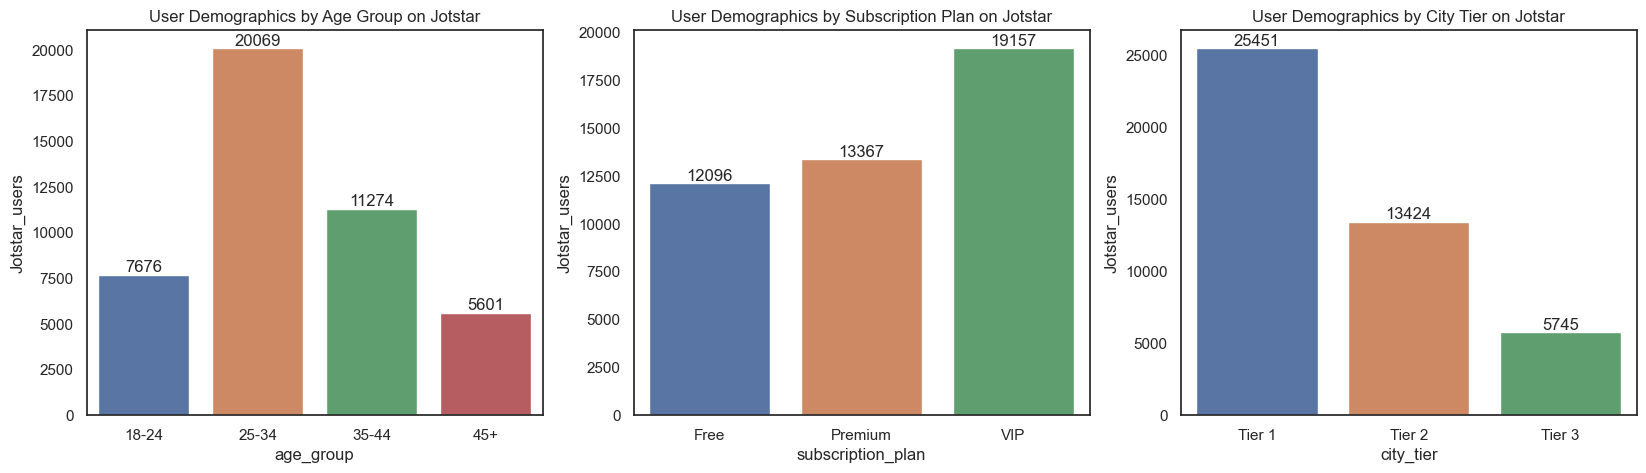

In [25]:
%matplotlib inline
sns.set_theme(rc={'figure.figsize': (20, 5)})
sns.set_style("white")

plt.subplot(1, 3, 1)
plt.title("User Demographics by Age Group on Jotstar")
ax1 = sns.barplot(data = user_demographics_age_group, x = 'age_group', y='Jotstar_users', hue='age_group')
for container in ax1.containers:
    ax1.bar_label(container)
plt.subplot(1, 3, 2)
plt.title("User Demographics by Subscription Plan on Jotstar")
ax2 = sns.barplot(data = user_demographics_jotstar, x = 'subscription_plan', y='Jotstar_users', hue='subscription_plan')
for container in ax2.containers:
    ax2.bar_label(container)

plt.subplot(1, 3, 3)
plt.title("User Demographics by City Tier on Jotstar")
ax3 = sns.barplot(data = user_demographics_city_tier, x = 'city_tier', y='Jotstar_users', hue='city_tier')
for container in ax3.containers:
    ax3.bar_label(container)

plt.show()

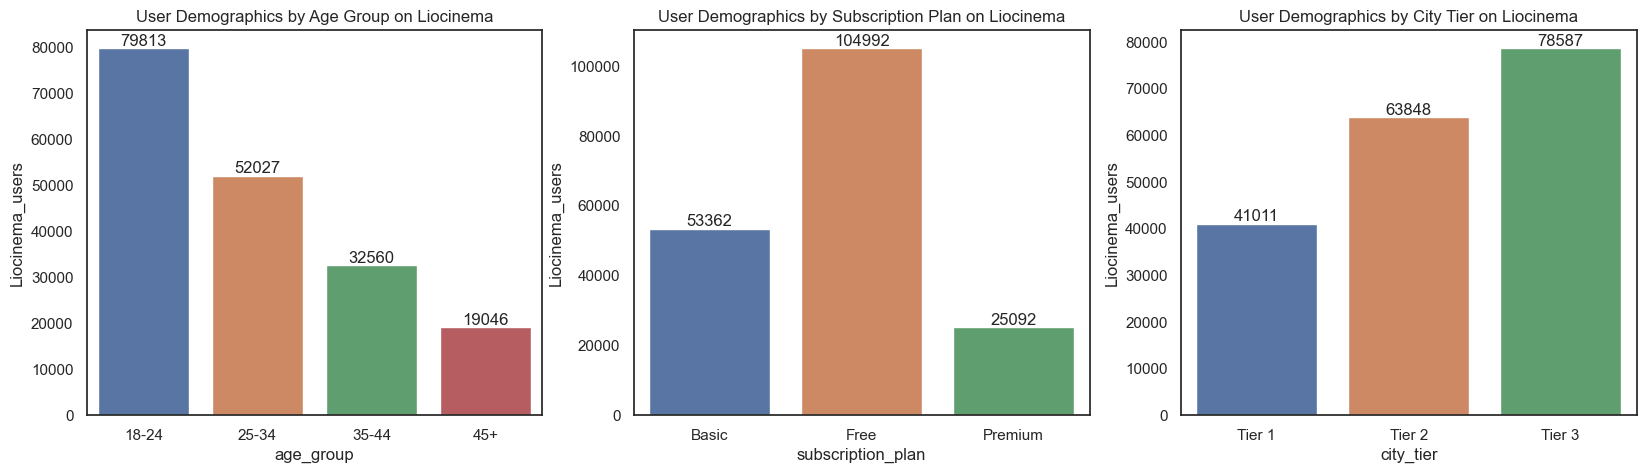

In [26]:

plt.subplot(1, 3, 1)
plt.title("User Demographics by Age Group on Liocinema")
ax1 = sns.barplot(data = user_demographics_age_group, x = 'age_group', y='Liocinema_users',hue='age_group')
for container in ax1.containers:
    ax1.bar_label(container)
    
plt.subplot(1, 3, 2)
plt.title("User Demographics by Subscription Plan on Liocinema")
ax2 = sns.barplot(data = user_demographics_liocinema, x = 'subscription_plan', y='Liocinema_users',hue='subscription_plan')
for container in ax2.containers:
    ax2.bar_label(container)
  
plt.subplot(1, 3, 3)
plt.title("User Demographics by City Tier on Liocinema")
ax3 = sns.barplot(data = user_demographics_city_tier, x = 'city_tier', y='Liocinema_users',hue='city_tier')
for container in ax3.containers:
    ax3.bar_label(container)

# Active vs. Inactive Users 
What percentage of LioCinema and Jotstar users are active vs. inactive? How do 
these rates vary by age group and subscription plan?

In [27]:
# convert the datatype of last actve date from object to datetime
Jotstar_subscribers['last_active_date'] = pd.to_datetime(Jotstar_subscribers['last_active_date'])   
Liocinema_subscribers['last_active_date'] = pd.to_datetime(Liocinema_subscribers['last_active_date'])

In [28]:
# For Jotstar and Liocinema if date is given then inactive (last active date) otherwise active if it is null.
Jotstar_subscribers['is_active'] = np.where(
    Jotstar_subscribers['last_active_date'].isnull(), 'Active User', 'Inactive User' 
)

Liocinema_subscribers['is_active'] = np.where(
    Liocinema_subscribers['last_active_date'].isnull(), 'Active User', 'Inactive User' 
)

TOTAL ACTIVE & INACTIVE USERS

In [29]:
Jotstar_subscribers_is_active = Jotstar_subscribers.groupby('is_active')['user_id'].count().reset_index()
Jotstar_subscribers_is_active['Percent %'] = round((Jotstar_subscribers_is_active.user_id / sum(Jotstar_subscribers_is_active.user_id) ) * 100)
Jotstar_subscribers_is_active = Jotstar_subscribers_is_active.rename(columns={'user_id': 'Total Users'})
Jotstar_subscribers_is_active


,is_active,Total Users,Percent %
0,Active User,37968,85.0
1,Inactive User,6652,15.0


In [30]:
Liocinema_subscribers_is_active = Liocinema_subscribers.groupby('is_active')['user_id'].count().reset_index()
Liocinema_subscribers_is_active['Percent %'] = round((Liocinema_subscribers_is_active.user_id /sum(Liocinema_subscribers_is_active.user_id) ) * 100)
Liocinema_subscribers_is_active = Liocinema_subscribers_is_active.rename(columns={'user_id': 'Total Users'})
Liocinema_subscribers_is_active

,is_active,Total Users,Percent %
0,Active User,101141,55.0
1,Inactive User,82305,45.0


ACTIVE & INACTIVE USER BY AGE GROUP

In [31]:
# Group by age_group and is_active
jotstar_age = Jotstar_subscribers.groupby(['age_group', 'is_active'])['user_id'].count().reset_index()

jotstar_age = jotstar_age.rename(columns={'user_id':'Total Users'})

total_by_age = jotstar_age.groupby('age_group')['Total Users'].transform('sum')

jotstar_age['Percent %'] = (jotstar_age['Total Users'] / total_by_age * 100).round(2)

jotstar_age

,age_group,is_active,Total Users,Percent %
0,18-24,Active User,6479,84.41
1,18-24,Inactive User,1197,15.59
2,25-34,Active User,16944,84.43
3,25-34,Inactive User,3125,15.57
4,35-44,Active User,9688,85.93
5,35-44,Inactive User,1586,14.07
6,45+,Active User,4857,86.72
7,45+,Inactive User,744,13.28


In [32]:
liocinema_age = Liocinema_subscribers.groupby(['age_group', 'is_active'])['user_id'].count().reset_index()

liocinema_age = liocinema_age.rename(columns={'user_id':'Total Users'})

total_by_age_liocinema = liocinema_age.groupby('age_group')['Total Users'].transform('sum')

liocinema_age['Percentage'] = (liocinema_age['Total Users'] / total_by_age_liocinema * 100).round(2)

liocinema_age


,age_group,is_active,Total Users,Percentage
0,18-24,Active User,40640,50.92
1,18-24,Inactive User,39173,49.08
2,25-34,Active User,29891,57.45
3,25-34,Inactive User,22136,42.55
4,35-44,Active User,19004,58.37
5,35-44,Inactive User,13556,41.63
6,45+,Active User,11606,60.94
7,45+,Inactive User,7440,39.06


ACTIVE AND INACTIVE USERS BASED ON SUBSCRIPTION PLAN

In [33]:
jotstar_plan = Jotstar_subscribers.groupby(['subscription_plan', 'is_active'])['user_id'].count().reset_index()

jotstar_plan = jotstar_plan.rename(columns={'user_id':'Total Users'})

total_by_plan = jotstar_plan.groupby('subscription_plan')['Total Users'].transform('sum')

jotstar_plan['Percentage'] = (jotstar_plan['Total Users'] / total_by_plan * 100).round(2)

jotstar_plan

,subscription_plan,is_active,Total Users,Percentage
0,Free,Active User,8983,74.26
1,Free,Inactive User,3113,25.74
2,Premium,Active User,12466,93.26
3,Premium,Inactive User,901,6.74
4,VIP,Active User,16519,86.23
5,VIP,Inactive User,2638,13.77


In [34]:
liocinema_plan = Liocinema_subscribers.groupby(['subscription_plan', 'is_active'])['user_id'].count().reset_index()

liocinema_plan = liocinema_plan.rename(columns={'user_id':'Total Users'})

total_by_plan_liocinema = liocinema_plan.groupby('subscription_plan')['Total Users'].transform('sum')
liocinema_plan['Percentage'] = (liocinema_plan['Total Users'] / total_by_plan_liocinema * 100).round(2)

liocinema_plan

,subscription_plan,is_active,Total Users,Percentage
0,Basic,Active User,35333,66.21
1,Basic,Inactive User,18029,33.79
2,Free,Active User,45199,43.05
3,Free,Inactive User,59793,56.95
4,Premium,Active User,20609,82.13
5,Premium,Inactive User,4483,17.87


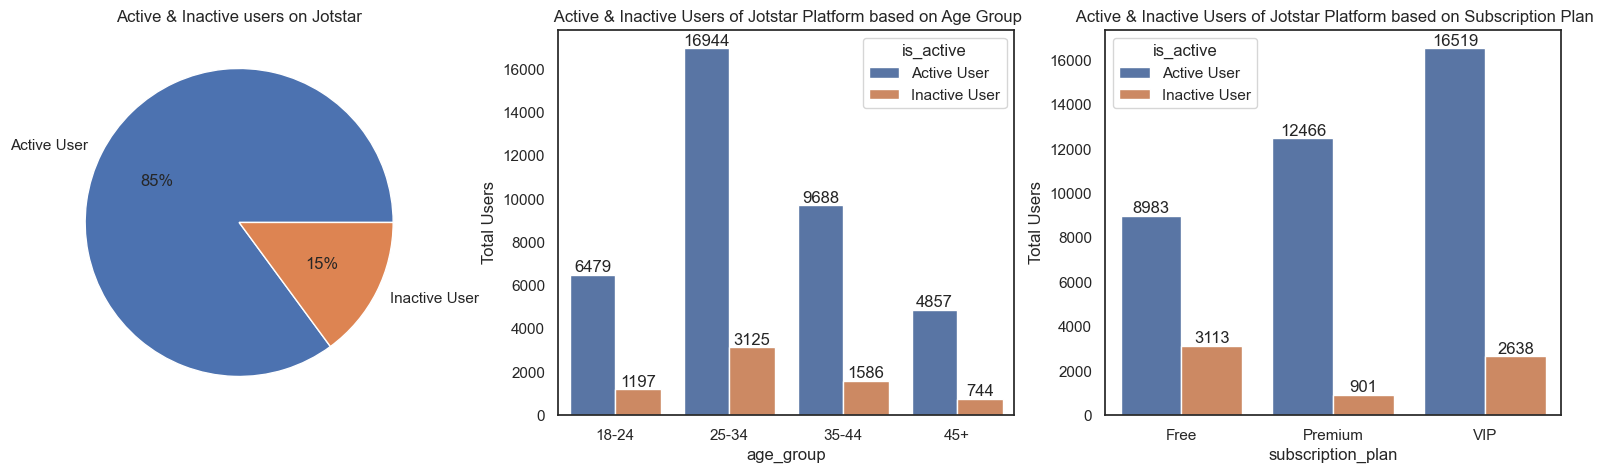

In [35]:
# LIOCINEMA PLATFORM

%matplotlib inline
sns.set_theme(rc={'figure.figsize': (20, 5)})
sns.set_style("white")

plt.subplot(1, 3, 1)
plt.title("Active & Inactive users on Jotstar")

ax1 = plt.pie(x = Jotstar_subscribers_is_active['Total Users'], labels=Jotstar_subscribers_is_active.is_active,autopct='%1.0f%%')
plt.subplot(1, 3, 2)
plt.title(' Active & Inactive Users of Jotstar Platform based on Age Group')
ax2 = sns.barplot(data=jotstar_age, x=jotstar_age.age_group, y=jotstar_age['Total Users'], hue=jotstar_age['is_active'])
for i in ax2.containers:
    ax2.bar_label(i,)

plt.subplot(1, 3, 3)
plt.title(' Active & Inactive Users of Jotstar Platform based on Subscription Plan')
ax3 = sns.barplot(data=jotstar_plan, x=jotstar_plan['subscription_plan'], y=jotstar_plan['Total Users'], hue=jotstar_plan['is_active'])
for i in ax3.containers:
    ax3.bar_label(i,)
    
plt.show()

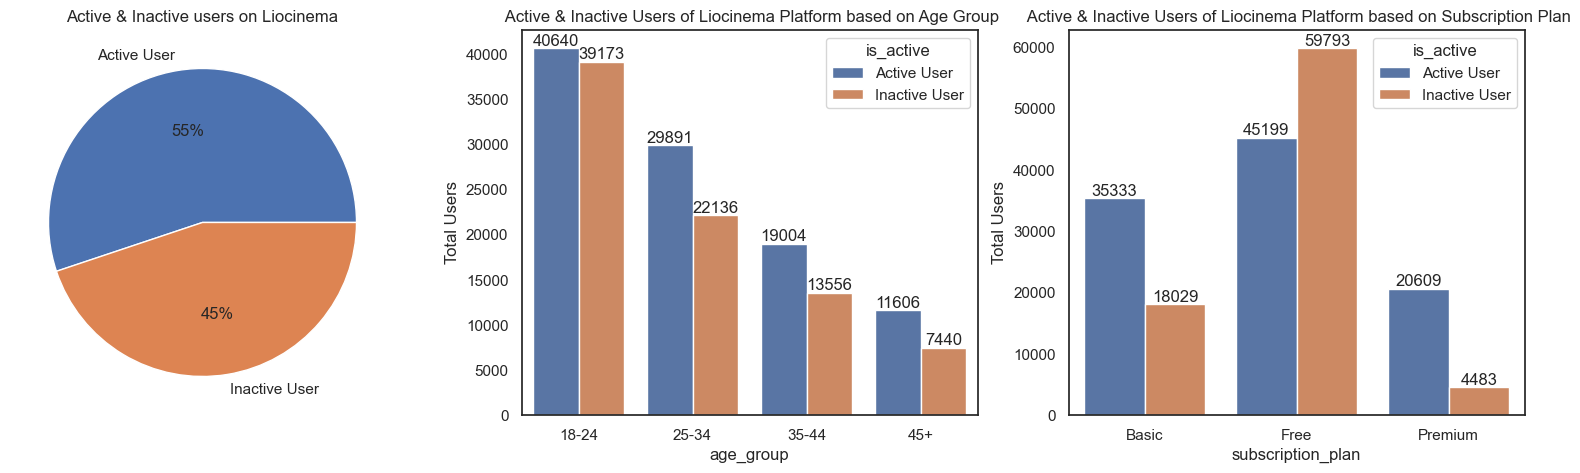

In [36]:
# JOTSTAR PLATFORM

%matplotlib inline
sns.set_theme(rc={'figure.figsize': (20, 5)})
sns.set_style("white")

plt.subplot(1, 3, 1)
plt.title("Active & Inactive users on Liocinema")
ax1 = plt.pie(x = Liocinema_subscribers_is_active['Total Users'], labels=Liocinema_subscribers_is_active.is_active,autopct='%1.0f%%')

plt.subplot(1, 3, 2)
plt.title(' Active & Inactive Users of Liocinema Platform based on Age Group')
ax2 = sns.barplot(data=liocinema_age, x=liocinema_age.age_group, y=liocinema_age['Total Users'], hue=liocinema_age['is_active'])
for i in ax2.containers:
    ax2.bar_label(i,)

plt.subplot(1, 3, 3)
plt.title(' Active & Inactive Users of Liocinema Platform based on Subscription Plan')
ax3 = sns.barplot(data=liocinema_plan, x=liocinema_plan['subscription_plan'], y=liocinema_plan['Total Users'], hue=liocinema_plan['is_active'])
for i in ax3.containers:
    ax3.bar_label(i,)
    
plt.show()

# Watch Time Analysis
What is the average watch time for LioCinema vs. Jotstar during the analysis period? 
How do these compare by city tier and device type?

In [37]:
# each user_id must be using different devices with different watch time
jotstar_time_analysis_df = pd.merge(Jotstar_content_consumption,Jotstar_subscribers, on='user_id')
jotstar_time_analysis_df.head()

,user_id,device_type,total_watch_time_mins,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan,is_active
0,UIDJS877cc0e02c9,Mobile,14613,45+,Tier 1,2024-04-05,VIP,NaT,NaN,NaN,Active User
1,UIDJS06384e7ff06,Mobile,13271,25-34,Tier 1,2024-05-21,Premium,NaT,NaN,NaN,Active User
2,UIDJSc3997b7beb7,Mobile,4644,18-24,Tier 3,2024-07-14,VIP,2024-11-12,NaN,NaN,Inactive User
3,UIDJS66726ce2325,Mobile,5734,18-24,Tier 1,2024-10-09,Premium,NaT,NaN,NaN,Active User
4,UIDJS040119b6107,Mobile,2939,35-44,Tier 1,2024-10-15,Free,NaT,2024-11-15,VIP,Active User


In [38]:
liocinema_time_analysis_df = pd.merge(Liocinema_content_consumption, Liocinema_subscribers, on = 'user_id',how='outer')
liocinema_time_analysis_df.head()

,user_id,device_type,total_watch_time_mins,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan,is_active
0,UIDLC00000bea68a,Mobile,1029,25-34,Tier 3,2024-10-24,Free,NaT,NaN,NaN,Active User
1,UIDLC00000bea68a,TV,134,25-34,Tier 3,2024-10-24,Free,NaT,NaN,NaN,Active User
2,UIDLC00000bea68a,Laptop,153,25-34,Tier 3,2024-10-24,Free,NaT,NaN,NaN,Active User
3,UIDLC00009202848,Mobile,4012,18-24,Tier 1,2024-09-18,Basic,NaT,NaN,NaN,Active User
4,UIDLC00009202848,TV,879,18-24,Tier 1,2024-09-18,Basic,NaT,NaN,NaN,Active User


AVERAGE WATCH TIME BY PLATFORM

In [39]:
# Total watch time of each user 
Jotstar_tot_watch_time = jotstar_time_analysis_df.groupby('user_id')['total_watch_time_mins'].sum().reset_index()
var_Jotstar_tot_watch_time = Jotstar_tot_watch_time.total_watch_time_mins.mean().round()
print(f'Avg watch time on Jotstar platform: {var_Jotstar_tot_watch_time} mins ')

Avg watch time on Jotstar platform: 21104.0 mins 


In [40]:
# Total watch time of each user 
Liocinema_tot_watch_time = liocinema_time_analysis_df.groupby('user_id')['total_watch_time_mins'].sum().reset_index()
var_Liocinema_tot_watch_time = Liocinema_tot_watch_time.total_watch_time_mins.mean().round()
print(f'Avg watch time on Liocinema platform: {var_Liocinema_tot_watch_time} mins')

Avg watch time on Liocinema platform: 3609.0 mins


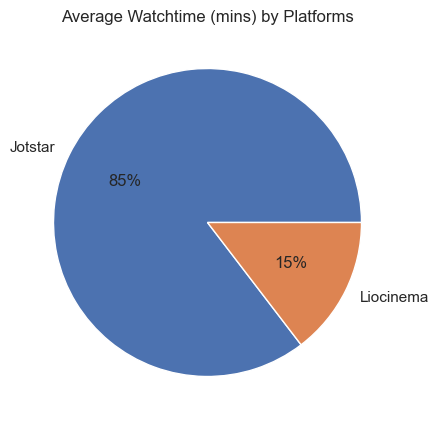

In [41]:
plt.pie(x=[var_Jotstar_tot_watch_time,var_Liocinema_tot_watch_time], labels=['Jotstar','Liocinema'], autopct='%1.0f%%')
plt.title('Average Watchtime (mins) by Platforms', loc='center')
plt.show()

AVERAGE WATCH TIME BY DEVICE TYPE

In [42]:
Jostar_avg_watching_device_time = jotstar_time_analysis_df.groupby(['user_id','device_type'])['total_watch_time_mins'].sum().reset_index()

Jostar_avg_watching_device_time_df = Jostar_avg_watching_device_time.groupby('device_type')['total_watch_time_mins'].mean().round(2).reset_index()
Jostar_avg_watching_device_time_df

,device_type,total_watch_time_mins
0,Laptop,4857.26
1,Mobile,10563.65
2,TV,5682.62


In [43]:
Liocinema_avg_watching_device_time  = liocinema_time_analysis_df.groupby(['user_id','device_type'])['total_watch_time_mins'].sum().reset_index()

Liocinema_avg_watching_device_time_df = Liocinema_avg_watching_device_time.groupby('device_type')['total_watch_time_mins'].mean().round(2).reset_index()

Liocinema_avg_watching_device_time_df

,device_type,total_watch_time_mins
0,Laptop,495.21
1,Mobile,2763.05
2,TV,759.29


In [44]:
Device_Watch_Time_Analysis_df = pd.merge(Jostar_avg_watching_device_time_df,Liocinema_avg_watching_device_time_df,on='device_type')

Device_Watch_Time_Analysis_df = Device_Watch_Time_Analysis_df.rename(columns={'total_watch_time_mins_x':'Jotstar Avg Watch Time', 'total_watch_time_mins_y':'Liocinema Avg Watch Time'})

Device_Watch_Time_Analysis_df

,device_type,Jotstar Avg Watch Time,Liocinema Avg Watch Time
0,Laptop,4857.26,495.21
1,Mobile,10563.65,2763.05
2,TV,5682.62,759.29


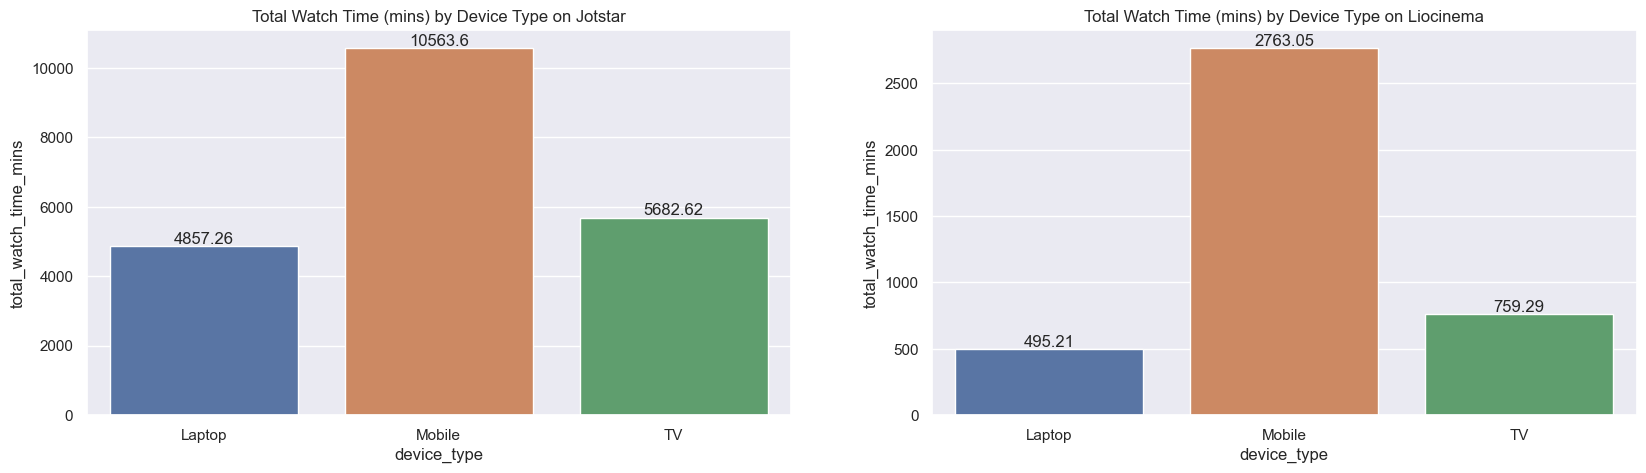

In [45]:
sns.set_theme(rc={'figure.figsize': (20, 5)})

plt.subplot(1,2,1)
plt.title('Total Watch Time (mins) by Device Type on Jotstar')
ax1 = sns.barplot(data=Jostar_avg_watching_device_time_df, x='device_type',y='total_watch_time_mins', hue='device_type')

for i in ax1.containers:
    ax1.bar_label(i,)

plt.subplot(1,2,2)
plt.title('Total Watch Time (mins) by Device Type on Liocinema')
ax2 = sns.barplot(data=Liocinema_avg_watching_device_time_df, x='device_type',y='total_watch_time_mins', hue='device_type')
for i in ax2.containers:
    ax2.bar_label(i,)


AVERAGE WATCH TIME BY CITY TIER

In [46]:
Jostar_avg_watch_city_tier_time = jotstar_time_analysis_df.groupby(['user_id','city_tier'])['total_watch_time_mins'].sum().reset_index()

Jostar_avg_watch_city_tier_time = Jostar_avg_watch_city_tier_time.groupby('city_tier')['total_watch_time_mins'].mean().round(2).reset_index()


In [47]:
Liocinema_avg_watch_city_tier_time  = liocinema_time_analysis_df.groupby(['user_id','city_tier'])['total_watch_time_mins'].sum().reset_index()

Liocinema_avg_watch_city_tier_time = Liocinema_avg_watch_city_tier_time.groupby('city_tier')['total_watch_time_mins'].mean().round(2).reset_index()


In [48]:
City_Watch_Time_Analysis_df = pd.merge(Jostar_avg_watch_city_tier_time, Liocinema_avg_watch_city_tier_time, on='city_tier')

City_Watch_Time_Analysis_df = City_Watch_Time_Analysis_df.rename(columns={'total_watch_time_mins_x':'Jotstar Avg Watch Time', 'total_watch_time_mins_y':'Liocinema Avg Watch Time'})

City_Watch_Time_Analysis_df

,city_tier,Jotstar Avg Watch Time,Liocinema Avg Watch Time
0,Tier 1,23650.96,5401.53
1,Tier 2,18901.01,4045.51
2,Tier 3,14964.61,2318.10


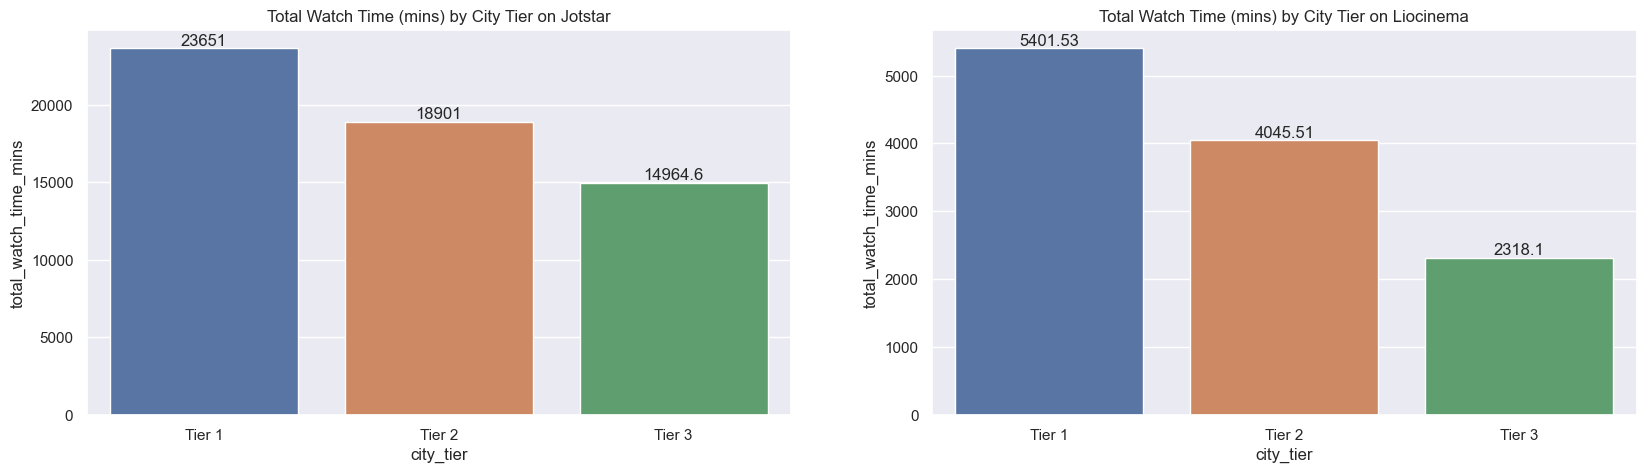

In [49]:
sns.set_theme(rc={'figure.figsize': (20, 5)})
plt.subplot(1,2,1)
plt.title('Total Watch Time (mins) by City Tier on Jotstar')
ax1 = sns.barplot(data=Jostar_avg_watch_city_tier_time, x='city_tier',y='total_watch_time_mins', hue='city_tier')
for i in ax1.containers:
    ax1.bar_label(i,)

plt.subplot(1,2,2)
plt.title('Total Watch Time (mins) by City Tier on Liocinema')
ax2 = sns.barplot(data=Liocinema_avg_watch_city_tier_time, x='city_tier',y='total_watch_time_mins', hue='city_tier')
for i in ax2.containers:
    ax2.bar_label(i,)

# Inactivity Correlation
How do inactivity patterns correlate with total watch time or average watch time? Are less engaged users more likely to become inactive?

In [50]:
# get unique user id and their watch time 
Jotstar_inactivity_correlation = jotstar_time_analysis_df.groupby(['user_id','is_active'])['total_watch_time_mins'].sum().dropna().reset_index()
Jotstar_inactivity_correlation.head()

,user_id,is_active,total_watch_time_mins
0,UIDJS0000751588f,Active User,40127
1,UIDJS000093eeb86,Active User,3868
2,UIDJS00010d7fa1e,Active User,9913
3,UIDJS00013411a85,Active User,21797
4,UIDJS0003a3f54cf,Active User,11531


In [51]:
Liocinema_inactivity_correlation = liocinema_time_analysis_df.groupby(['user_id','is_active'])['total_watch_time_mins'].sum().dropna().reset_index()
Liocinema_inactivity_correlation

,user_id,is_active,total_watch_time_mins
0,UIDLC00000bea68a,Active User,1316
1,UIDLC00009202848,Active User,5515
2,UIDLC0001086afc3,Active User,12224
3,UIDLC000186abd93,Inactive User,631
4,UIDLC0002189b09f,Active User,3775
...,...,...,...
183441,UIDLCffff41ace17,Inactive User,251
183442,UIDLCffff85ea59a,Active User,6808
183443,UIDLCffffbb55ff5,Active User,1043
183444,UIDLCffffc6f6db0,Inactive User,7266


In [52]:
Inactivity_correlation_stats = pd.DataFrame(
    columns= ['platform','Total watch time (mins) AVG','Active users avg watch time', 'Inactive users avg watch time'],
)
Inactivity_correlation_stats['platform'] = pd.Series(['Jotstar','Liocinema'])

Inactivity_correlation_stats['Total watch time (mins) AVG'] = pd.Series([
    Jotstar_inactivity_correlation['total_watch_time_mins'].mean().round(0),
    Liocinema_inactivity_correlation['total_watch_time_mins'].mean().round(0)
])

Inactivity_correlation_stats['Active users avg watch time'] = pd.Series([
Jotstar_inactivity_correlation[Jotstar_inactivity_correlation['is_active'] == 'Active User']['total_watch_time_mins'].mean().round(0),
Liocinema_inactivity_correlation[Liocinema_inactivity_correlation['is_active'] == 'Active User']['total_watch_time_mins'].mean().round(0),
])

Inactivity_correlation_stats['Inactive users avg watch time'] = pd.Series([
Jotstar_inactivity_correlation[Jotstar_inactivity_correlation['is_active'] == 'Inactive User']['total_watch_time_mins'].mean().round(0),
Liocinema_inactivity_correlation[Liocinema_inactivity_correlation['is_active'] == 'Inactive User']['total_watch_time_mins'].mean().round(0),
])

Inactivity_correlation_stats


,platform,Total watch time (mins) AVG,Active users avg watch time,Inactive users avg watch time
0,Jotstar,21104.0,23765.0,5913.0
1,Liocinema,3609.0,5642.0,1110.0


##### JOTSTAR MONTHLY AVG WATCH TIME ANALYSIS

In [53]:
monthly_watch_time_trend = jotstar_time_analysis_df.groupby([jotstar_time_analysis_df['subscription_date'].dt.to_period('M'),'is_active']).agg({'total_watch_time_mins':'mean'}).reset_index()
monthly_watch_time_trend['subscription_date'] = monthly_watch_time_trend['subscription_date'].astype('str')
monthly_watch_time_trend['total_watch_time_mins'] = monthly_watch_time_trend['total_watch_time_mins'].round(0)
monthly_watch_time_trend 


,subscription_date,is_active,total_watch_time_mins
0,2024-01,Active User,16056.0
1,2024-01,Inactive User,3820.0
2,2024-02,Active User,14168.0
3,2024-02,Inactive User,3059.0
4,2024-03,Active User,12619.0
5,2024-03,Inactive User,2571.0
6,2024-04,Active User,10918.0
7,2024-04,Inactive User,2099.0
8,2024-05,Active User,9397.0
9,2024-05,Inactive User,2102.0


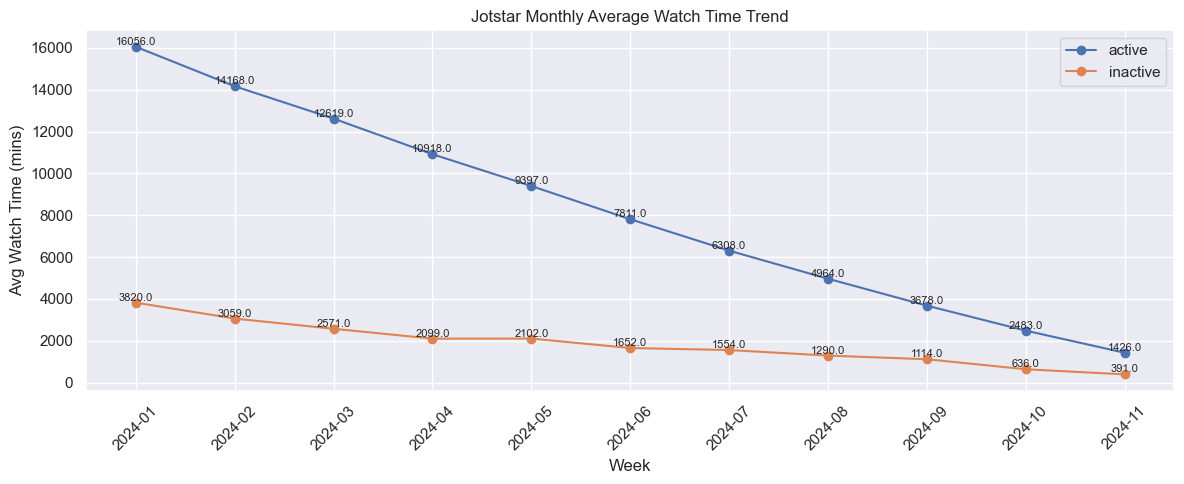

In [54]:

plt.figure(figsize=(12,5))

x = monthly_watch_time_trend['subscription_date'].unique()
y1 = monthly_watch_time_trend[monthly_watch_time_trend['is_active'] == 'Active User']['total_watch_time_mins']
y2 = monthly_watch_time_trend[monthly_watch_time_trend['is_active'] == 'Inactive User']['total_watch_time_mins']

plt.plot(x , y1, marker='o',label='Active users')
plt.plot(x, y2,marker='o',label='Inactive users')

# Add labels for Jotstar
for i, value in enumerate(y1):
    plt.text(x[i], value, str(value), fontsize=8, ha='center', va='bottom')

for i, value in enumerate(y2):
    plt.text(x[i], value, str(value), fontsize=8, ha='center', va='bottom')

plt.title("Jotstar Monthly Average Watch Time Trend")
plt.xlabel("Week")
plt.ylabel("Avg Watch Time (mins)")
plt.legend(['active','inactive'])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


##### LIOCINEMA MONTHLY AVG WATCH TIME ANALYSIS

In [55]:
monthly_watch_time_trend_liocinema = liocinema_time_analysis_df.groupby([liocinema_time_analysis_df['subscription_date'].dt.to_period('M'),'is_active']).agg({'total_watch_time_mins':'mean'}).reset_index()
monthly_watch_time_trend_liocinema['subscription_date'] = monthly_watch_time_trend_liocinema['subscription_date'].astype('str')
monthly_watch_time_trend_liocinema['total_watch_time_mins'] = monthly_watch_time_trend_liocinema['total_watch_time_mins'].round(0)
monthly_watch_time_trend_liocinema 


,subscription_date,is_active,total_watch_time_mins
0,2024-01,Active User,7111.0
1,2024-01,Inactive User,2036.0
2,2024-02,Active User,6301.0
3,2024-02,Inactive User,1710.0
4,2024-03,Active User,5484.0
5,2024-03,Inactive User,1286.0
6,2024-04,Active User,4645.0
7,2024-04,Inactive User,1023.0
8,2024-05,Active User,3563.0
9,2024-05,Inactive User,868.0


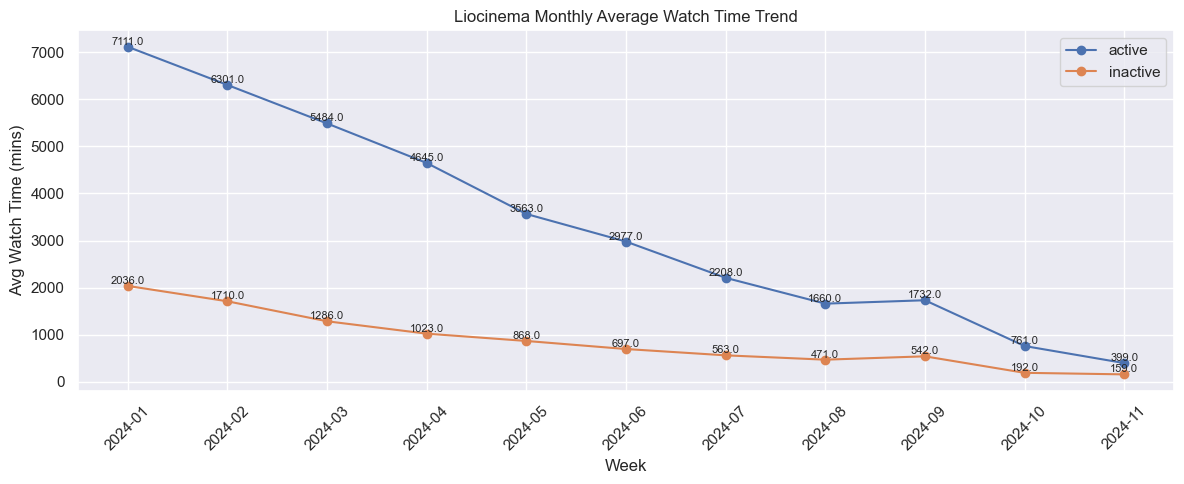

In [56]:

plt.figure(figsize=(12,5))

ax = monthly_watch_time_trend_liocinema['subscription_date'].unique()
ay1 = monthly_watch_time_trend_liocinema[monthly_watch_time_trend['is_active'] == 'Active User']['total_watch_time_mins']
ay2 = monthly_watch_time_trend_liocinema[monthly_watch_time_trend['is_active'] == 'Inactive User']['total_watch_time_mins']

plt.plot(ax , ay1, marker='o',label='Active users')
plt.plot(ax, ay2,marker='o',label='Inactive users')

# Add labels for Liocinema
for i, value in enumerate(ay1):
    plt.text(ax[i], value, str(value), fontsize=8, ha='center', va='bottom')

for i, value in enumerate(ay2):
    plt.text(ax[i], value, str(value), fontsize=8, ha='center', va='bottom')

plt.title("Liocinema Monthly Average Watch Time Trend")
plt.xlabel("Week")
plt.ylabel("Avg Watch Time (mins)")
plt.legend(['active','inactive'])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Downgrade Trends
How do downgrade trends differ between LioCinema and Jotstar? Are downgrades 
more prevalent on one platform compared to the other?

In [75]:
Liocinema_subscribers_downgrade = Liocinema_subscribers.groupby(['subscription_plan','new_subscription_plan'])['user_id'].count().reset_index().drop(index=[1,2,3]).reset_index(drop=True)
Liocinema_subscribers_downgrade 

,subscription_plan,new_subscription_plan,user_id
0,Basic,Free,10309
1,Premium,Basic,3111
2,Premium,Free,7439


In [76]:
# premium > VIP 
Jotstar_subscribers_downgrade = Jotstar_subscribers.groupby(['subscription_plan','new_subscription_plan'])['user_id'].count().reset_index().drop(index=[0,1,5]).reset_index(drop=True)
Jotstar_subscribers_downgrade

,subscription_plan,new_subscription_plan,user_id
0,Premium,Free,225
1,Premium,VIP,368
2,VIP,Free,2149


In [ ]:
jotstar_tot_user = Jotstar_subscribers['user_id'].nunique()
liocinema_tot_user = Liocinema_subscribers['user_id'].nunique()

In [79]:
Platform_downgrade_df = pd.DataFrame(
    {
    'Platform':['Jotstar','Liocinema'],
    'Downgrades':[Jotstar_subscribers_downgrade.user_id.sum(),
                    Liocinema_subscribers_downgrade.user_id.sum()],
    'Total Users':[jotstar_tot_user,liocinema_tot_user],
    'Downgrade Rate':[((Jotstar_subscribers_downgrade.user_id.sum() / jotstar_tot_user) * 100).round(2),
                      ((Liocinema_subscribers_downgrade.user_id.sum() / liocinema_tot_user)*100).round(2)]
    
    }
)
Platform_downgrade_df

,Platform,Downgrades,Total Users,Downgrade Rate
0,Jotstar,2742,44620,6.15
1,Liocinema,20859,183446,11.37


# Upgrade Patterns 
What are the most common upgrade transitions (e.g., Free to Basic, Free to VIP, Free to Premium) for LioCinema and Jotstar? How do these differ across platforms?

In [59]:
plan_tiers = {'VIP': 3, 'Premium': 2, 'Basic': 1, 'Free': 0}

# Filter plan change records
# 1. the plan chage date should not be null and the old plan < new changed plan
Liocinema_upgrades = Liocinema_subscribers[
    (Liocinema_subscribers['plan_change_date'].notna()) &
    (Liocinema_subscribers['subscription_plan'].map(plan_tiers) < Liocinema_subscribers['new_subscription_plan'].map(plan_tiers))
].reset_index()

Liocinema_upgrades.head(3)

,index,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan,is_active
0,8,UIDLC00044bbb294,25-34,Tier 2,2024-04-09,Free,NaT,2024-09-09,Basic,Active User
1,16,UIDLC0007b26e5f0,25-34,Tier 1,2024-07-27,Basic,NaT,2024-09-27,Premium,Active User
2,21,UIDLC0008d7e1bd3,35-44,Tier 1,2024-07-04,Basic,NaT,2024-11-04,Premium,Active User


In [60]:
Liocinema_subscribers_upgrade = Liocinema_upgrades.groupby(['subscription_plan','new_subscription_plan'])['user_id'].count().reset_index()
Liocinema_subscribers_upgrade

,subscription_plan,new_subscription_plan,user_id
0,Basic,Premium,1362
1,Free,Basic,2078
2,Free,Premium,715


In [61]:
# premium > VIP 

plan_tiers2 = {'Premium': 2, 'VIP': 1, 'Free': 0}

Jotstar_upgrades = Jotstar_subscribers[
    (Jotstar_subscribers['plan_change_date'].notna()) &
    (Jotstar_subscribers['subscription_plan'].map(plan_tiers2) < Jotstar_subscribers['new_subscription_plan'].map(plan_tiers2))
].reset_index()

Jotstar_upgrades.head()

,index,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan,is_active
0,76,UIDJS006315e24bf,45+,Tier 1,2024-01-04,Free,NaT,2024-03-04,Premium,Active User
1,81,UIDJS006711c9331,25-34,Tier 1,2024-05-22,Free,NaT,2024-06-22,VIP,Active User
2,88,UIDJS00753e2f5d5,25-34,Tier 3,2024-04-04,VIP,NaT,2024-05-04,Premium,Active User
3,89,UIDJS007b5054731,25-34,Tier 1,2024-03-19,Free,NaT,2024-09-19,VIP,Active User
4,94,UIDJS0084cfde42c,35-44,Tier 1,2024-02-13,VIP,NaT,2024-03-13,Premium,Active User


In [62]:
Jotstar_subscribers_upgrade = Jotstar_upgrades.groupby(['subscription_plan','new_subscription_plan'])['user_id'].count().reset_index()
Jotstar_subscribers_upgrade

,subscription_plan,new_subscription_plan,user_id
0,Free,Premium,683
1,Free,VIP,844
2,VIP,Premium,2821


In [73]:
Platform_upgrade_df = pd.DataFrame(
    {
    'Platform':['Jotstar','Liocinema'],
    'Upgrades':[Jotstar_subscribers_upgrade.user_id.sum(),
                    Liocinema_subscribers_upgrade.user_id.sum()],
    'Total Users':[jotstar_tot_user,liocinema_tot_user],
    'Upgrade Rate':[((Jotstar_subscribers_upgrade.user_id.sum()/jotstar_tot_user)*100).round(2),((Liocinema_subscribers_upgrade.user_id.sum()/liocinema_tot_user)*100).round(2)]
    
    } 
)
Platform_upgrade_df

,Platform,Upgrades,Total Users,Upgrade Rate
0,Jotstar,4348,44620,9.74
1,Liocinema,4155,183446,2.26


# Paid Users Distribution 
How does the paid user percentage (e.g., Basic, Premium for LioCinema; VIP, Premium for Jotstar) vary across different platforms? Analyse the proportion of premium users in Tier 1, Tier 2, and Tier 3 cities and identify any notable trends or differences.

In [ ]:
Jotstar_paid_user = Jotstar_subscribers.groupby(['city_tier','subscription_plan'])['user_id'].count().unstack()
Jotstar_paid_user = Jotstar_paid_user.drop(columns=['Free'])
Jotstar_paid_user['Total User'] = Jotstar_subscribers.groupby('city_tier')['user_id'].count()
Jotstar_paid_user['(VIP + Premium)'] = Jotstar_paid_user.Premium + Jotstar_paid_user.VIP
Jotstar_paid_user['Paid user %'] = (Jotstar_paid_user['(VIP + Premium)'] / Jotstar_paid_user['Total User'] * 100).round(2)
Jotstar_paid_user['VIP Plan %'] = (Jotstar_paid_user['VIP'] / Jotstar_paid_user['Total User'] * 100).round(2)
Jotstar_paid_user['Premium Plan %'] = (Jotstar_paid_user['Premium'] / Jotstar_paid_user['Total User'] * 100).round(2)

Jotstar_paid_user



subscription_plan,Premium,VIP,Total User,(VIP + Premium),Paid user %,VIP Plan %,Premium Plan %
city_tier,,,,,,,
Tier 1,10178,10162,25451,20340,79.92,39.93,39.99
Tier 2,2566,6794,13424,9360,69.73,50.61,19.12
Tier 3,623,2201,5745,2824,49.16,38.31,10.84


In [ ]:
Liocinema_paid_user = Liocinema_subscribers.groupby(['city_tier','subscription_plan'])['user_id'].count().unstack()
Liocinema_paid_user = Liocinema_paid_user.drop(columns=['Free'])
Liocinema_paid_user['Total User'] = Liocinema_subscribers.groupby('city_tier')['user_id'].count()
Liocinema_paid_user['(Basic + Premium)'] = Liocinema_paid_user.Basic + Liocinema_paid_user.Premium
Liocinema_paid_user['Paid user %'] = (Liocinema_paid_user['(Basic + Premium)'] / Liocinema_paid_user['Total User'] * 100).round(2)
Liocinema_paid_user['Basic Plan %'] = (Liocinema_paid_user['Basic'] / Liocinema_paid_user['Total User'] * 100).round(2)
Liocinema_paid_user['Premium Plan %'] = (Liocinema_paid_user['Premium'] / Liocinema_paid_user['Total User'] * 100).round(2)

Liocinema_paid_user


subscription_plan,Basic,Premium,Total User,(Basic + Premium),Paid user %,Basic Plan %,Premium Plan %
city_tier,,,,,,,
Tier 1,12293,10306,41011,22599,55.10,29.97,25.13
Tier 2,22570,9090,63848,31660,49.59,35.35,14.24
Tier 3,18499,5696,78587,24195,30.79,23.54,7.25


# Revenue Analysis 
Assume the following monthly subscription prices, calculate the total revenue generated by both platforms (LioCinema and Jotstar) for the analysis period (January to November 2024). 

The calculation should consider: 
- Subscribers count under each plan. 
- Active duration of subscribers on their respective plans. 
- Upgrades and downgrades during the period, ensuring revenue reflects the time spent under each plan. 

In [ ]:
# Monthly Subscription Prices
Liocinema_basic_plan = 96
Liocinema_premium_plan = 129
Jotstar_vip_plan = 159
Jotstar_premium_plan = 359

Month = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}

## Jotstar Revenue Analysis

In [ ]:
Jotstar_subscribers_revenue = Jotstar_subscribers.copy().drop(columns=['is_active'])

# create a columns or latest subscription plan of all the users
Jotstar_subscribers_revenue['latest_subscription_plan'] = np.where(Jotstar_subscribers_revenue['new_subscription_plan'].isna(), Jotstar_subscribers_revenue['subscription_plan'], Jotstar_subscribers_revenue['new_subscription_plan'])

Jotstar_subscribers_revenue.head(10)

In [ ]:
# those user who are active that is either the are active given a certain date in the last active date or they have changed the plan so plan date is last active sate 
Jotstar_subscribers_revenue['plan_change_date'] = pd.to_datetime(Jotstar_subscribers_revenue['plan_change_date'])

''' For end date the logic is if the last active date is not present for some users 
1. They must have logged in for changing plan so take that date 
2. For others the last active date would be the end date of november '''

Jotstar_subscribers_revenue['subscription_end_date'] = np.where(Jotstar_subscribers_revenue['last_active_date'].isna(),np.datetime64('2024-11-30'),Jotstar_subscribers_revenue['last_active_date'])


# an active months columns 
Jotstar_subscribers_revenue['Active_Months'] = (Jotstar_subscribers_revenue['subscription_end_date'].dt.month - Jotstar_subscribers_revenue['subscription_date'].dt.month) + 1
Jotstar_subscribers_revenue.head(10)

In [ ]:
plan_tiers

In [ ]:
# check the plan status whether it is upgraded , downgraded or not change at all
Jotstar_subscribers_revenue['plan_change_status'] = np.where(
    (Jotstar_subscribers_revenue['new_subscription_plan'].notna()) & 
    (Jotstar_subscribers_revenue['subscription_plan'].map(plan_tiers) < 
     Jotstar_subscribers_revenue['new_subscription_plan'].map(plan_tiers)),
    'Upgrade',
    np.where(
        (Jotstar_subscribers_revenue['new_subscription_plan'].notna()) & 
        (Jotstar_subscribers_revenue['subscription_plan'].map(plan_tiers) > 
         Jotstar_subscribers_revenue['new_subscription_plan'].map(plan_tiers)),
        'Downgrade',
        'No Change'
    )
)
Jotstar_subscribers_revenue.head(20)

In [ ]:
# Subscribers count under each plan. 
Jotstar_subscribers_revenue.groupby('latest_subscription_plan')['user_id'].count().reset_index()


In [ ]:
# Active duration of subscribers on their respective plans. 
# how many users were active for how many months 
Jotstar_subscribers_revenue.groupby(['latest_subscription_plan','Active_Months',])['user_id'].count().unstack().fillna(0).drop(index=['Free']).reset_index()

In [ ]:
# Upgrades and downgrades during the period, ensuring revenue reflects the time spent under each plan. 
Jotstar_Revenue_Analysis = Jotstar_subscribers_revenue.groupby(['plan_change_status','Active_Months','latest_subscription_plan'])['user_id'].count().unstack().fillna(0).drop(columns=['Free']).reset_index()
Jotstar_Revenue_Analysis

In [ ]:
Jotstar_Revenue_Analysis['Monthly Premium Price'] = Jotstar_Revenue_Analysis['Premium']*Jotstar_premium_plan
Jotstar_Revenue_Analysis['Monthly VIP Price'] = Jotstar_Revenue_Analysis['VIP']*Jotstar_vip_plan
# users  + the price they pay * for how many months they were active 
Jotstar_Revenue_Analysis['Total Revenue'] = (Jotstar_Revenue_Analysis['Monthly Premium Price'] + Jotstar_Revenue_Analysis['Monthly VIP Price'])* Jotstar_Revenue_Analysis['Active_Months']
Jotstar_Revenue_Analysis['Month Name'] = Jotstar_Revenue_Analysis['Active_Months'].map(Month)

Jotstar_Revenue_Analysis

In [ ]:
print('Total Revenue of Jotstar: ')
Jotstar_Revenue_Analysis['Total Revenue'].sum()

In [ ]:
revenue_jotstar = Jotstar_Revenue_Analysis.groupby('Month Name')['Total Revenue'].sum().reset_index().sort_values(by='Total Revenue', ascending=False)
revenue_jotstar['revenue distribution percentage'] =  round((revenue_jotstar['Total Revenue'] / revenue_jotstar['Total Revenue'].sum()) * 100,1)
revenue_jotstar

In [ ]:
sns.set_theme(rc={'figure.figsize': (10, 6)})
ax = sns.barplot(data=revenue_jotstar, x=revenue_jotstar['revenue distribution percentage'], y=revenue_jotstar['Month Name'],hue=revenue_jotstar['Month Name'],errorbar=None,palette='Paired', width=0.5, orient='h')
plt.title('Revenue Distribution of Jotstar Platform')
for i in ax.containers:
    ax.bar_label(i,)


## Liocinema Revenue Analysis

In [ ]:
Liocinema_subscribers_revenue = Liocinema_subscribers.copy().drop(columns=['is_active'])
Liocinema_subscribers_revenue

FIND OUT ALL THE LATEST SUBSCRIPTION PLAN OF USERS SINCE THEY MAY HAVE CHANGED IT

In [ ]:
Liocinema_subscribers_revenue['latest_subscription_plan'] = np.where(
    Liocinema_subscribers_revenue['new_subscription_plan'].isna(),
    Liocinema_subscribers_revenue['subscription_plan'],Liocinema_subscribers_revenue['new_subscription_plan'])
Liocinema_subscribers_revenue.head(15)

TO FIND OUT THE ACTIVE DURATIONS MONTHS OF EACH SUBSCRIBERS ON RESPECTIVE PLANS

In [ ]:
# Change datatype to datetype of plan change date

Liocinema_subscribers_revenue['plan_change_date'] = pd.to_datetime(Liocinema_subscribers_revenue['plan_change_date'])

# If users is having a last active date then use that otherwise consider November as their last acitve date

Liocinema_subscribers_revenue['subscription_end_date'] = np.where(
    Liocinema_subscribers_revenue['last_active_date'].isna(), np.datetime64('2024-11-30'), Liocinema_subscribers_revenue['last_active_date'])


# Duration of Active Months of each user
Liocinema_subscribers_revenue['Active_Months'] = (Liocinema_subscribers_revenue['subscription_end_date'].dt.month - Liocinema_subscribers_revenue['subscription_date'].dt.month) + 1


Liocinema_subscribers_revenue.head(20)

CHECK THE SUBSCRIPTION PLAN STATUS WHETHER IT IS CHANGED OR NOT

In [ ]:
plan_tiers = {'Free':0, 'Basic':1,'Premium':2}
Liocinema_subscribers_revenue['plan_change_status']  = np.where(
    (Liocinema_subscribers_revenue['new_subscription_plan'].notna()) &
    (Liocinema_subscribers_revenue['subscription_plan'].map(plan_tiers) <
     Liocinema_subscribers_revenue['new_subscription_plan'].map(plan_tiers)),
     'Upgrade',
     np.where(
         (Liocinema_subscribers_revenue['new_subscription_plan'].notna()) &
         (Liocinema_subscribers_revenue['subscription_plan'].map(plan_tiers) >
          Liocinema_subscribers_revenue['new_subscription_plan'].map(plan_tiers)),
          'Downgrade',
          'No Change'
     )
)

Liocinema_subscribers_revenue

In [ ]:
Liocinema_subscribers_revenue.groupby('latest_subscription_plan')['user_id'].count().reset_index()

In [ ]:
Liocinema_subscribers_revenue.groupby(['latest_subscription_plan','Active_Months'])['user_id'].count().unstack().fillna(0).drop(index=['Free']).reset_index()

In [ ]:
Liocinema_Revenue_Analysis = Liocinema_subscribers_revenue.groupby(['plan_change_status','Active_Months','latest_subscription_plan'])['user_id'].count().unstack().fillna(0).drop(columns=['Free']).reset_index()
Liocinema_Revenue_Analysis.head(50)

In [ ]:
Liocinema_Revenue_Analysis['Monthly Basic Price'] = Liocinema_Revenue_Analysis['Basic'] * Liocinema_basic_plan
Liocinema_Revenue_Analysis['Monthly Premium Price'] = Liocinema_Revenue_Analysis['Premium'] * Liocinema_premium_plan

Liocinema_Revenue_Analysis['Total Revenue'] = (Liocinema_Revenue_Analysis['Monthly Basic Price'] + Liocinema_Revenue_Analysis['Monthly Premium Price']) * Liocinema_Revenue_Analysis['Active_Months']

Liocinema_Revenue_Analysis['Month Name'] = Liocinema_Revenue_Analysis['Active_Months'].map(Month)

Liocinema_Revenue_Analysis

In [ ]:
print('Total Revenue of Liocinema: ')
Liocinema_Revenue_Analysis['Total Revenue'].sum()

In [ ]:
revenue_liocinema = Liocinema_Revenue_Analysis.groupby('Month Name')['Total Revenue'].sum().reset_index().sort_values(by='Total Revenue', ascending=False)
revenue_liocinema['revenue distribution percentage'] = round((revenue_liocinema['Total Revenue'] / revenue_liocinema['Total Revenue'].sum())*100,1)
revenue_liocinema

In [ ]:
sns.set_theme(rc={'figure.figsize': (10, 6)})
ax = sns.barplot(data=revenue_liocinema, x=revenue_liocinema['revenue distribution percentage'], y=revenue_liocinema['Month Name'],hue=revenue_liocinema['Month Name'],errorbar=None,palette='Paired', width=0.5, orient='h')
plt.title('Revenue Distribution of Liocinema Platform')
for i in ax.containers:
    ax.bar_label(i,)